In [51]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import pandas_datareader.data as web
import statsmodels.api as sm
from statsmodels.regression.quantile_regression import QuantReg

import warnings
warnings.filterwarnings("ignore")

In [75]:
tickers = ["^GSPC","VVIAX"]
raw = yf.download(tickers, start="2010-01-01", end="2023-12-31", auto_adjust=True, interval="1mo")["Close"]
raw_ret = raw.pct_change().dropna()
raw_ret.index = raw_ret.index.to_period("M").to_timestamp()
raw_ret.head()

[*********************100%***********************]  2 of 2 completed


Ticker,VVIAX,^GSPC
Date,,
2010-02-01,0.025867,0.028514
2010-03-01,0.055794,0.058796
2010-04-01,0.023710,0.014759
2010-05-01,-0.077844,-0.081976
2010-06-01,-0.057359,-0.053882


In [76]:
#  Fetch FAMA-French 3-Factor data

ff_data = web.DataReader("F-F_Research_Data_Factors", "famafrench", start="2010-01-01", end="2023-12-31")[0]
ff_data.head()

,Mkt-RF,SMB,HML,RF
Date,,,,
2010-01,-3.35,0.43,0.33,0.00
2010-02,3.39,1.18,3.18,0.00
2010-03,6.30,1.46,2.19,0.01
2010-04,1.99,4.84,2.96,0.01
2010-05,-7.90,0.13,-2.48,0.01


In [77]:
ff_data.index = pd.to_datetime(ff_data.index.to_timestamp())
ff_data = ff_data / 100
ff_data.head()

,Mkt-RF,SMB,HML,RF
Date,,,,
2010-01-01,-0.0335,0.0043,0.0033,0.0000
2010-02-01,0.0339,0.0118,0.0318,0.0000
2010-03-01,0.0630,0.0146,0.0219,0.0001
2010-04-01,0.0199,0.0484,0.0296,0.0001
2010-05-01,-0.0790,0.0013,-0.0248,0.0001


In [78]:
# Align and build excess returns
data = raw_ret.join(ff_data, how="inner")

# Excess Return = funds returns - risk free rate
data["fund_excess"] = data["VVIAX"] - data["RF"]
data["sp500_excess"] = data["^GSPC"] - data["RF"]

factors = ["Mkt-RF", "SMB", "HML"]
X = sm.add_constant(data[factors])
data.head()

,VVIAX,^GSPC,Mkt-RF,SMB,HML,RF,fund_excess,sp500_excess
Date,,,,,,,,
2010-02-01,0.025867,0.028514,0.0339,0.0118,0.0318,0.0000,0.025867,0.028514
2010-03-01,0.055794,0.058796,0.0630,0.0146,0.0219,0.0001,0.055694,0.058696
2010-04-01,0.023710,0.014759,0.0199,0.0484,0.0296,0.0001,0.023610,0.014659
2010-05-01,-0.077844,-0.081976,-0.0790,0.0013,-0.0248,0.0001,-0.077944,-0.082076
2010-06-01,-0.057359,-0.053882,-0.0556,-0.0179,-0.0473,0.0001,-0.057459,-0.053982


In [79]:
# OLS Baseline
ols_fund = sm.OLS(data["fund_excess"], X).fit()
ols_sp500 = sm.OLS(data["sp500_excess"], X).fit()

print("----Fund OLS----")
print(ols_fund.summary())
print("----SNP OLS----")
print(ols_sp500.summary())

----Fund OLS----
                            OLS Regression Results                            
Dep. Variable:            fund_excess   R-squared:                       0.959
Model:                            OLS   Adj. R-squared:                  0.959
Method:                 Least Squares   F-statistic:                     1286.
Date:                Fri, 05 Jun 2026   Prob (F-statistic):          3.45e-113
Time:                        12:16:48   Log-Likelihood:                 556.87
No. Observations:                 167   AIC:                            -1106.
Df Residuals:                     163   BIC:                            -1093.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0003      0.001   

In [80]:
# Quantile Regression
quantiles = [round(q, 2) for q in [0.10, 0.25, 0.50, 0.75, 0.90]]

def run_quantile_reg(y, X, quantiles):
    model = QuantReg(y, X)
    results = {}
    for q in quantiles:
        res = model.fit(q=q, vcov='iid', max_iter=1000)
        key = round(q, 2) 
        results[key] = {
            'params': res.params,
            'ci_lower': res.params - 1.96 * res.bse,
            'ci_upper': res.params + 1.96 * res.bse
        }
    return results
    
qr_fund = run_quantile_reg(data["fund_excess"], X, quantiles)
qr_sp500 = run_quantile_reg(data["sp500_excess"], X, quantiles)

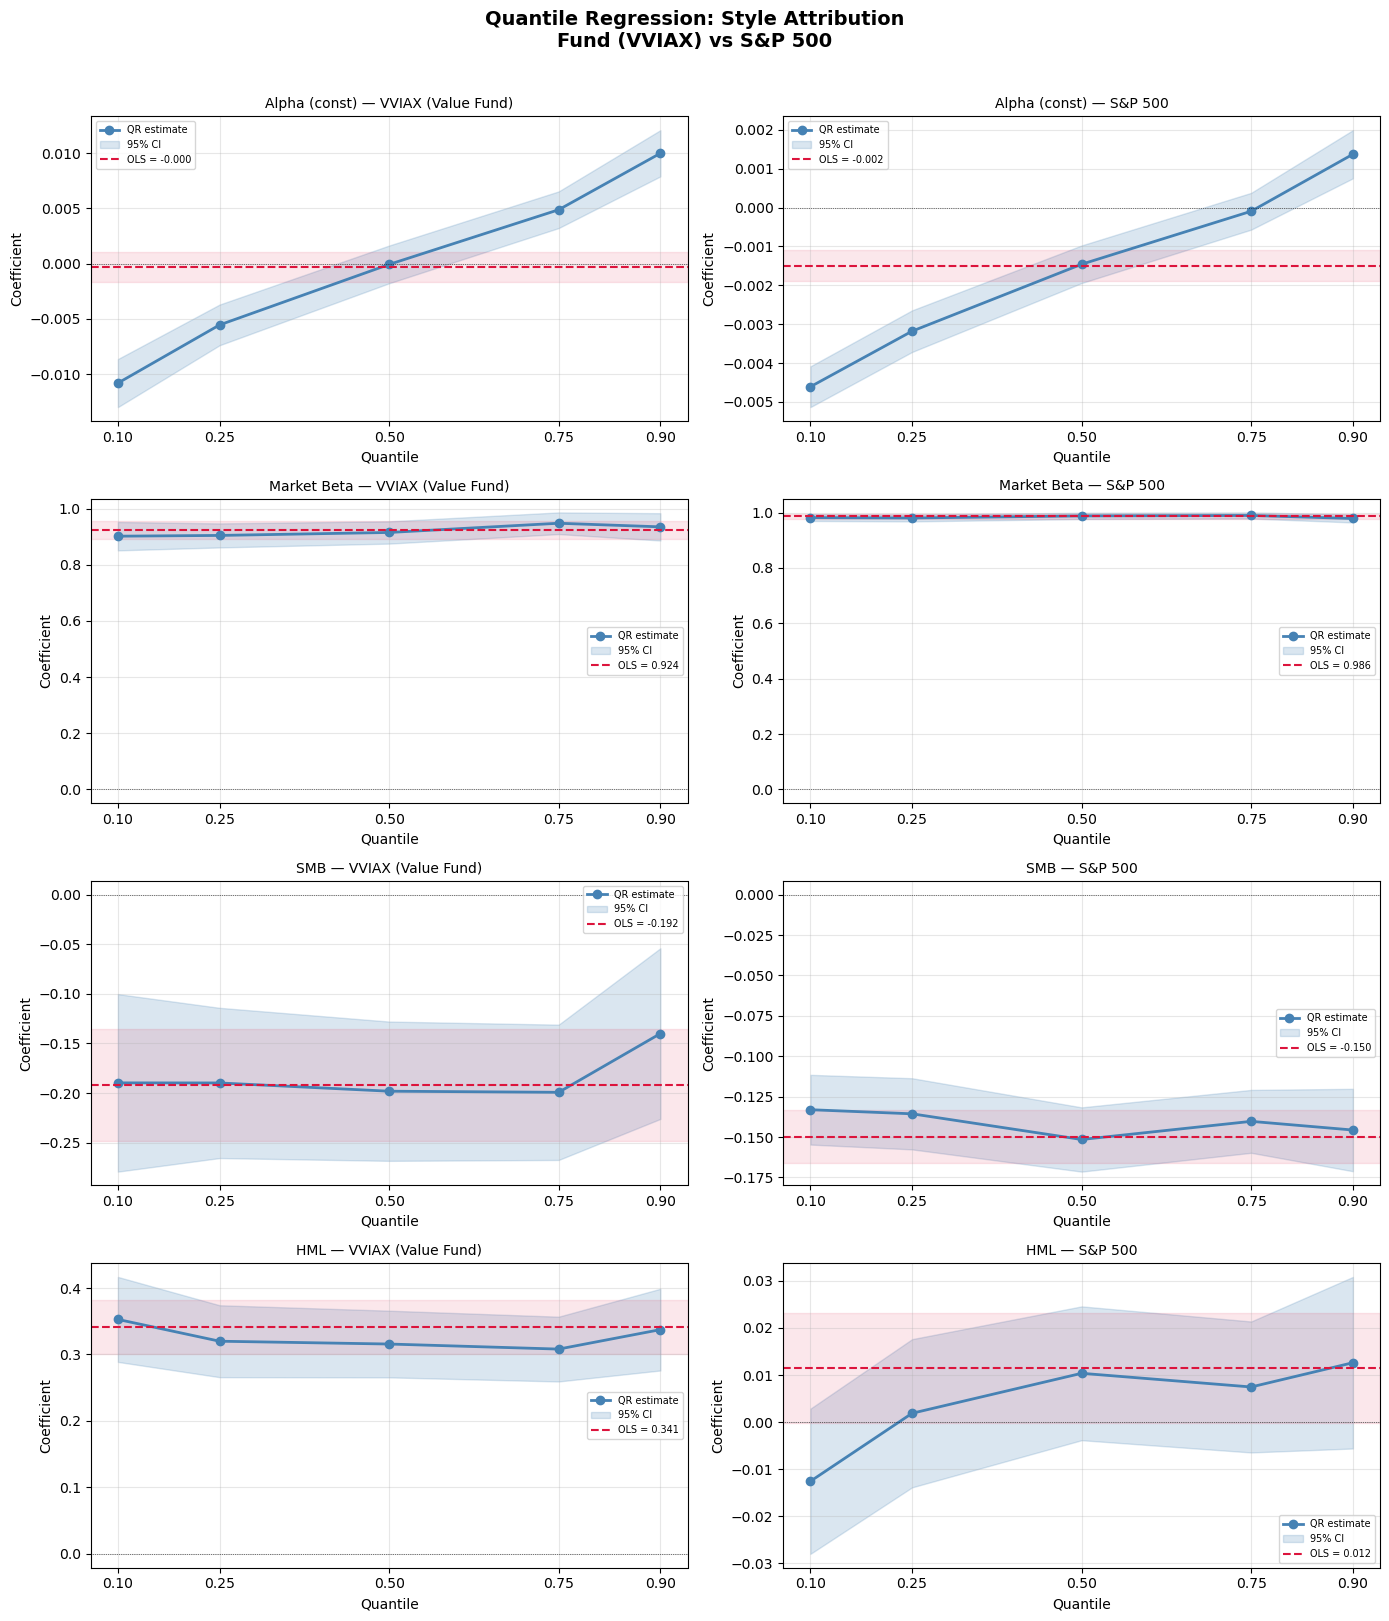

In [81]:
# PLOT: factor loadings across quantiles

param_names = ['const', 'Mkt-RF', 'SMB', 'HML']
labels      = ['Alpha (const)', 'Market Beta', 'SMB', 'HML']

fig, axes = plt.subplots(len(param_names), 2, figsize=(14, 16))
fig.suptitle("Quantile Regression: Style Attribution\nFund (VVIAX) vs S&P 500", 
             fontsize=14, fontweight='bold', y=1.01)

for i, (param, label) in enumerate(zip(param_names, labels)):

    for j, (qr_results, ols_res, title) in enumerate([
        (qr_fund,  ols_fund,  'VVIAX (Value Fund)'),
        (qr_sp500, ols_sp500, 'S&P 500')
    ]):
        ax = axes[i, j]

        coefs  = [qr_results[q]['params'].loc[param]   for q in quantiles]
        lowers = [qr_results[q]['ci_lower'].loc[param] for q in quantiles]
        uppers = [qr_results[q]['ci_upper'].loc[param] for q in quantiles]
        
        ax.plot(quantiles, coefs, 'o-', color='steelblue', 
                linewidth=2, markersize=6, label='QR estimate')
        ax.fill_between(quantiles, lowers, uppers, 
                        alpha=0.2, color='steelblue', label='95% CI')

        # OLS flat line
        ols_coef = ols_res.params[param]
        ols_ci   = 1.96 * ols_res.bse[param]
        ax.axhline(ols_coef, color='crimson', linestyle='--', 
                   linewidth=1.5, label=f'OLS = {ols_coef:.3f}')
        ax.axhspan(ols_coef - ols_ci, ols_coef + ols_ci, 
                   alpha=0.1, color='crimson')

        ax.axhline(0, color='black', linewidth=0.5, linestyle=':')
        ax.set_title(f"{label} — {title}", fontsize=10)
        ax.set_xlabel("Quantile")
        ax.set_ylabel("Coefficient")
        ax.set_xticks(quantiles)
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('quantile_style_attribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [83]:
# SUMMARY TABLE: COEFFICIENT SHIFTS ACROSS QUANTILES
rows = []
for q in quantiles:
    row = {'Quantile': q}
    for p in param_names:
        row[p] = round(qr_fund[q]['params'].loc[p], 4)
    rows.append(row)

df_fund_summary = pd.DataFrame(rows).set_index('Quantile')
df_fund_summary.columns = labels
print(df_fund_summary)

rows = []
for q in quantiles:
    row = {'Quantile': q}
    for p in param_names:
        row[p] = round(qr_sp500[q]['params'].loc[p], 4)
    rows.append(row)

df_sp500_summary = pd.DataFrame(rows).set_index('Quantile')
df_sp500_summary.columns = labels
print(df_sp500_summary)

          Alpha (const)  Market Beta     SMB     HML
Quantile                                            
0.10            -0.0108       0.9021 -0.1897  0.3528
0.25            -0.0055       0.9048 -0.1898  0.3200
0.50            -0.0001       0.9154 -0.1981  0.3157
0.75             0.0049       0.9482 -0.1992  0.3081
0.90             0.0100       0.9354 -0.1400  0.3374
          Alpha (const)  Market Beta     SMB     HML
Quantile                                            
0.10            -0.0046       0.9817 -0.1331 -0.0125
0.25            -0.0032       0.9803 -0.1356  0.0019
0.50            -0.0015       0.9878 -0.1515  0.0104
0.75            -0.0001       0.9893 -0.1403  0.0075
0.90             0.0014       0.9785 -0.1457  0.0126
